In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hesh97/titanicdataset-traincsv")

print("Path to dataset files:", path)

Path to dataset files: /home/md-naim/.cache/kagglehub/datasets/hesh97/titanicdataset-traincsv/versions/1


In [29]:
from pathlib import Path
dataset_fies = list(Path(path).rglob("*.csv"))

In [30]:
data = pd.read_csv(dataset_fies[0])


In [31]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [33]:
data['Pclass'].unique()

array([3, 1, 2])

In [34]:
data["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [35]:
data.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

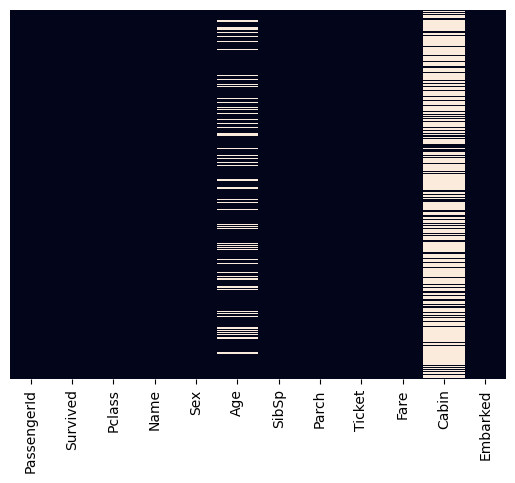

In [36]:
sns.heatmap(
    data.isnull(),
    yticklabels=False,
    cbar=False, 
)

In [37]:
data.drop(
    columns=['Cabin'],
    inplace=True
)

<Axes: >

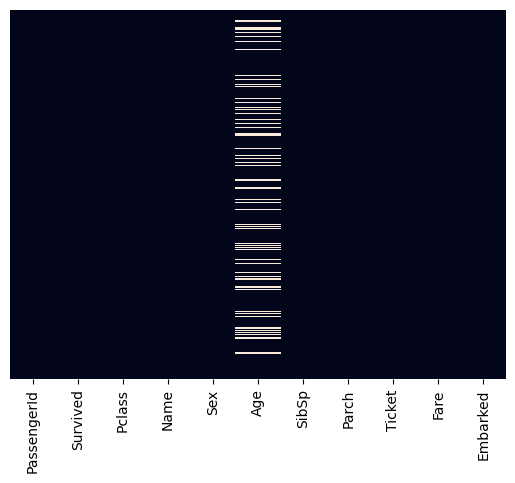

In [38]:
sns.heatmap(
    data.isnull(),
    yticklabels=False,
    cbar=False
)

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


<Axes: xlabel='Sex', ylabel='Age'>

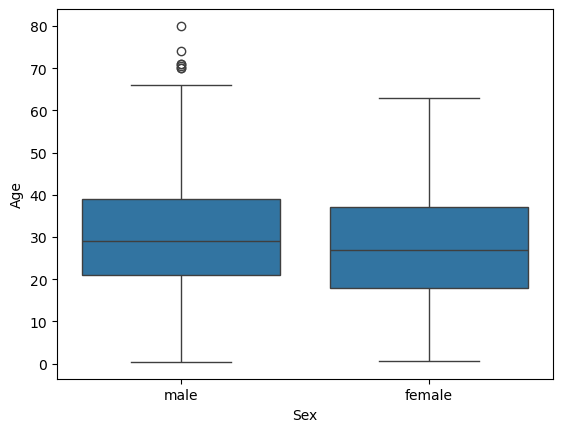

In [40]:
sns.boxplot(
    data=data,
    x='Sex',
    y='Age'
)

<Axes: xlabel='Survived', ylabel='Age'>

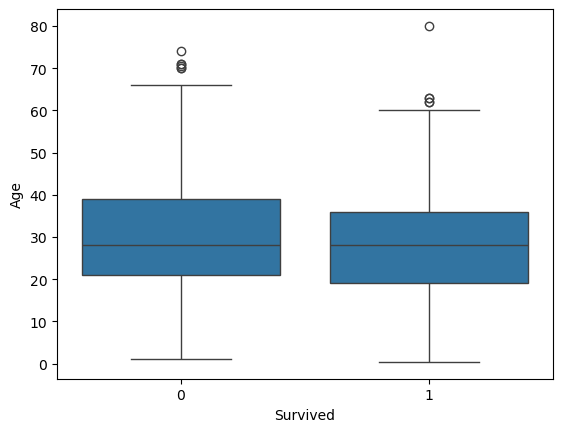

In [41]:
sns.boxplot(
    data=data,
    x='Survived',
    y='Age'
)

<Axes: xlabel='Pclass', ylabel='Age'>

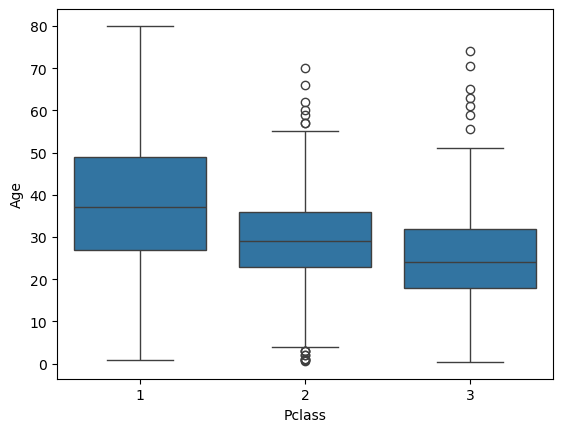

In [42]:
sns.boxplot(
    data=data,
    x='Pclass',
    y='Age'
)

In [43]:
pclass_1_median = data[data['Pclass'] == 1]['Age'].median()
pclass_2_median = data[data['Pclass'] == 2]['Age'].median()
pclass_3_median = data[data['Pclass'] == 3]['Age'].median()

In [44]:
pclass_1_median, pclass_2_median, pclass_3_median

(37.0, 29.0, 24.0)

In [45]:
def fill_age(columns):
    Age = columns.iloc['Age']
    Pclass = columns.iloc['Pclass']

    if pd.isnull(Age):
        if Pclass == 1:
            return pclass_1_median
        elif Pclass == 2:
            return pclass_2_median
        else:
            return pclass_3_median

    else:
        return Age

In [46]:
data['Age'] = data[['Age', 'Pclass']].apply(fill_age, axis=1)

TypeError: Cannot index by location index with a non-integer key

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


<Axes: >

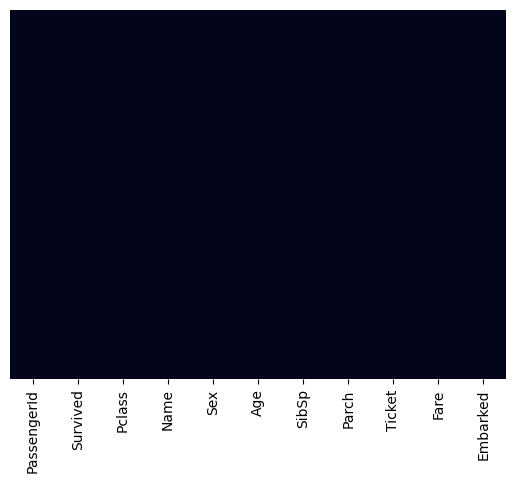

In [ ]:
plt.Figure(figsize=(7,7))


sns.heatmap(
    data.isnull(),
    yticklabels=False, 
    cbar=False
)

In [ ]:
data.dropna(inplace=True)

<Axes: >

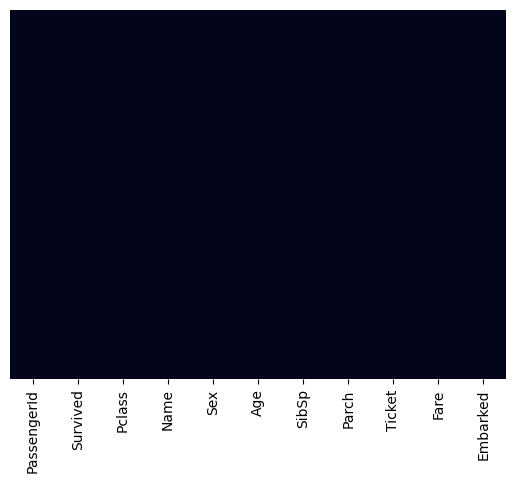

In [ ]:
plt.Figure(figsize=(7,7))


sns.heatmap(
    data.isnull(),
    yticklabels=False, 
    cbar=False
)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [ ]:
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB
